# Sensitivity Analysis — Outliers (Stage 07)
**Name:** Jesse Wang
**Date:** 2026-08-20

Companion to the pipeline's Stage-07 step. It loads the cleaned daily-return
panel and answers two questions a portfolio manager cares about:

1. **Volatility** — how much do the mean/std of daily returns change when outliers
   are kept, dropped, or winsorized?
2. **Correlation** — do tail events distort each ETF's beta vs SPY?

Full assumptions and risks are in [`docs/outliers.md`](../docs/outliers.md); the
functions live in [`src/outliers.py`](../src/outliers.py).

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                    # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))     # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
# imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from src import io, outliers

%matplotlib inline
np.random.seed(17)

## 1) Load the cleaned returns and detect outliers

In [3]:
RAW, PROC = io.get_paths()

# latest cleaned return panel (timestamped filenames, newest last)
cleaned_files = sorted(Path(PROC).glob('etf_returns_cleaned_*.csv'))
cleaned_path = cleaned_files[-1]
df = io.read_df(cleaned_path)
print('loaded:', cleaned_path.name)
print('shape:', df.shape, '| tickers:', df['ticker'].unique().tolist())
df.head()

loaded: etf_returns_cleaned_20260820-160228.csv
shape: (1250, 4) | tickers: ['GLD', 'IWM', 'QQQ', 'SPY', 'TLT']


,date,ticker,close,return
0,2025-08-22,GLD,310.579987,0.010706
1,2025-08-25,GLD,309.829987,-0.002415
2,2025-08-26,GLD,312.079987,0.007262
3,2025-08-27,GLD,312.709991,0.002019
4,2025-08-28,GLD,315.029999,0.007419


In [4]:
# detect within each ticker (each ETF has its own volatility)
df['outlier_z'] = outliers.flag_outliers(df, method='zscore', threshold=3.0)
df['outlier_iqr'] = outliers.flag_outliers(df, method='iqr', k=1.5)

print('Z-score (threshold=3):')
print(outliers.summarize_outliers(df, method='zscore'))
print()
print('IQR (k=1.5):')
print(outliers.summarize_outliers(df, method='iqr'))

Z-score (threshold=3):
       flagged  fraction
GLD          3    0.0120
IWM          2    0.0080
QQQ          1    0.0040
SPY          4    0.0160
TLT          1    0.0040
total       11    0.0088

IQR (k=1.5):
       flagged  fraction
GLD         16    0.0640
IWM          5    0.0200
QQQ          9    0.0360
SPY          9    0.0360
TLT          4    0.0160
total       43    0.0344


## 2) Sensitivity — volatility (mean & std)

The treatment for outliers directly changes the **volatility estimate**, which is
what risk bands and position sizes are built on.

In [5]:
def _summ(s):
    return pd.Series({'mean': s.mean(), 'std': s.std()})

winsor = outliers.winsorize_outliers(df)   # 5%/95% per ticker

# pooled
pooled = pd.DataFrame({
    'all':          _summ(df['return']),
    'filtered_z':   _summ(df.loc[~df['outlier_z'], 'return']),
    'winsorized':   _summ(winsor),
}).T
print('Pooled (all tickers):')
pooled.round(6)

Pooled (all tickers):


,mean,std
all,0.000829,0.012091
filtered_z,0.000969,0.011197
winsorized,0.000835,0.010312


In [6]:
# per-ticker std — where do outliers matter most?
per_tk = []
for tk, g in df.groupby('ticker'):
    m = g['outlier_z']
    per_tk.append({
        'ticker': tk,
        'std_all': g['return'].std(),
        'std_filtered': g.loc[~m, 'return'].std(),
        'std_winsorized': outliers.winsorize_outliers(g).std(),
        'flagged': int(m.sum()),
    })
per_tk = pd.DataFrame(per_tk).set_index('ticker')
per_tk['std_drop_pct'] = (1 - per_tk['std_filtered'] / per_tk['std_all']) * 100
per_tk.round(5)

,std_all,std_filtered,std_winsorized,flagged,std_drop_pct
ticker,,,,,
GLD,0.01817,0.01602,0.01480,3,11.82486
IWM,0.01207,0.01164,0.01069,2,3.53640
QQQ,0.01237,0.01199,0.01085,1,3.02366
SPY,0.00813,0.00744,0.00718,4,8.46935
TLT,0.00609,0.00598,0.00538,1,1.74407


## 3) Sensitivity — correlation (beta vs SPY)

For a rotation strategy the cross-asset **beta** matters. Do the tail days move
each ETF's beta vs the market (SPY)?

In [7]:
def _beta(x, y):
    X = x.to_numpy().reshape(-1, 1); yv = y.to_numpy()
    m = LinearRegression().fit(X, yv); pred = m.predict(X)
    return pd.Series({'beta': m.coef_[0], 'intercept': m.intercept_,
                      'r2': r2_score(yv, pred), 'mae': mean_absolute_error(yv, pred)})

# pivot to wide (rows = date, cols = ticker)
wide = df.pivot(index='date', columns='ticker', values='return')
wide_out = df.pivot(index='date', columns='ticker', values='outlier_z')

rows = []
for tk in ['GLD', 'IWM', 'QQQ', 'TLT']:
    sub = pd.DataFrame({'x': wide['SPY'], 'y': wide[tk], 'o': wide_out[tk]}).dropna()
    all_b = _beta(sub['x'], sub['y'])
    flt_b = _beta(sub.loc[~sub['o'], 'x'], sub.loc[~sub['o'], 'y'])
    rows.append({'ticker': tk,
                 'beta_all': all_b['beta'], 'beta_filtered': flt_b['beta'],
                 'r2_all': all_b['r2'], 'r2_filtered': flt_b['r2']})
beta_tbl = pd.DataFrame(rows).set_index('ticker')
beta_tbl.round(4)

,beta_all,beta_filtered,r2_all,r2_filtered
ticker,,,,
GLD,0.6990,0.7111,0.0978,0.1309
IWM,1.2175,1.1911,0.6726,0.6585
QQQ,1.4110,1.3915,0.8603,0.8547
TLT,0.1795,0.1623,0.0575,0.0479


## 4) Visual comparison

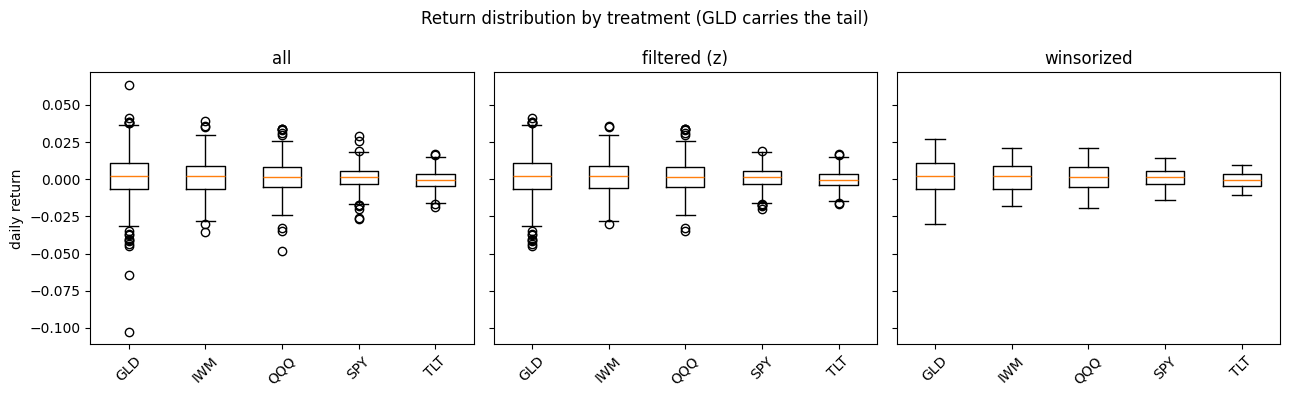

In [8]:
# 4a. Boxplot of returns under each treatment, per ticker
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
treatments = {
    'all':          df.groupby('ticker')['return'].apply(list).tolist(),
    'filtered (z)': df.loc[~df['outlier_z']].groupby('ticker')['return'].apply(list).tolist(),
    'winsorized':   df.assign(w=winsor).groupby('ticker')['w'].apply(list).tolist(),
}
tickers = df['ticker'].unique().tolist()
for ax, (name, data) in zip(axes, treatments.items()):
    ax.boxplot(data, tick_labels=tickers)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('daily return')
fig.suptitle('Return distribution by treatment (GLD carries the tail)')
plt.tight_layout(); plt.show()

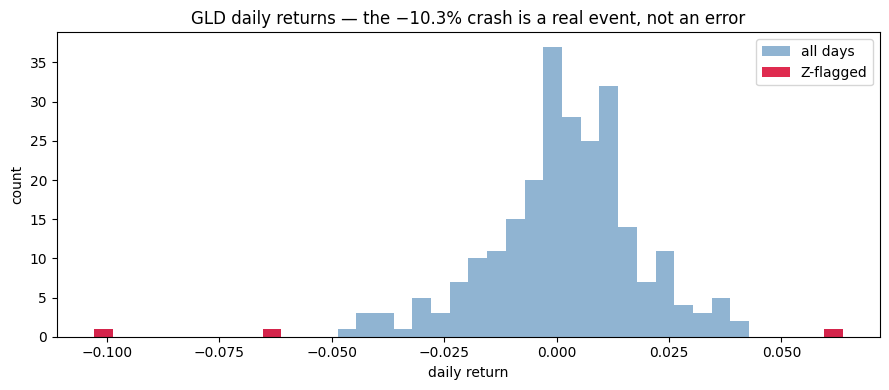

In [9]:
# 4b. GLD — histogram with the Z-flagged tail days highlighted
gld = df[df['ticker'] == 'GLD'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(gld['return'], bins=40, alpha=0.6, color='steelblue', label='all days')
ax.hist(gld.loc[gld['outlier_z'], 'return'], bins=40, alpha=0.9,
        color='crimson', label='Z-flagged')
ax.set_xlabel('daily return'); ax.set_ylabel('count')
ax.set_title('GLD daily returns — the −10.3% crash is a real event, not an error')
ax.legend()
plt.tight_layout(); plt.show()

/opt/anaconda3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


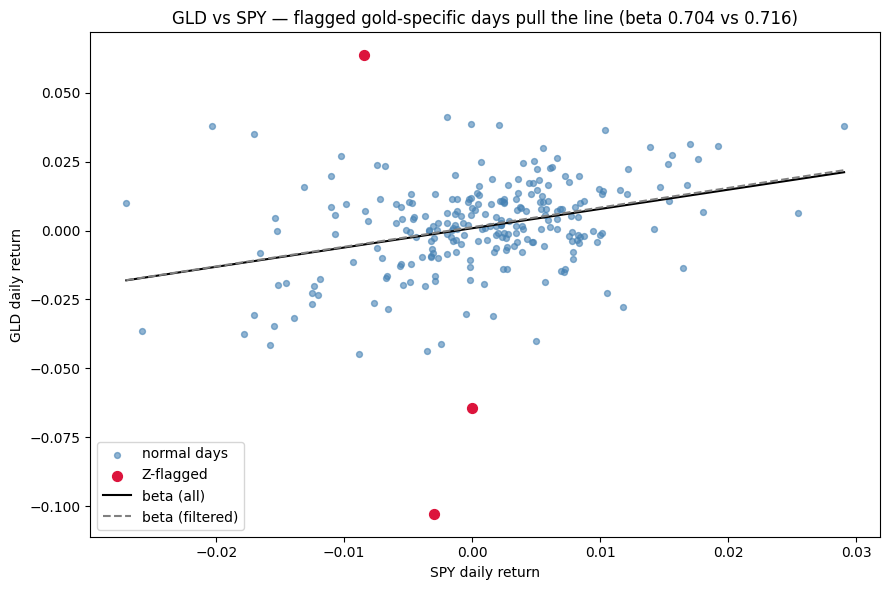

In [10]:
# 4c. GLD vs SPY — the crash day sits far off the market line
gld_wide = pd.DataFrame({'x': wide['SPY'], 'y': wide['GLD'], 'o': wide_out['GLD']}).dropna()
m_all = LinearRegression().fit(gld_wide[['x']], gld_wide['y'])
m_flt = LinearRegression().fit(gld_wide.loc[~gld_wide['o'], ['x']], gld_wide.loc[~gld_wide['o'], 'y'])

xs = np.linspace(gld_wide['x'].min(), gld_wide['x'].max(), 50)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(gld_wide.loc[~gld_wide['o'], 'x'], gld_wide.loc[~gld_wide['o'], 'y'],
           s=18, alpha=0.6, color='steelblue', label='normal days')
ax.scatter(gld_wide.loc[gld_wide['o'], 'x'], gld_wide.loc[gld_wide['o'], 'y'],
           s=50, color='crimson', label='Z-flagged')
ax.plot(xs, m_all.predict(xs.reshape(-1, 1)), color='k', lw=1.5, label='beta (all)')
ax.plot(xs, m_flt.predict(xs.reshape(-1, 1)), color='gray', lw=1.5, ls='--',
        label='beta (filtered)')
ax.set_xlabel('SPY daily return'); ax.set_ylabel('GLD daily return')
ax.set_title('GLD vs SPY — flagged gold-specific days pull the line (beta 0.704 vs 0.716)')
ax.legend()
plt.tight_layout(); plt.show()

## 5) Output

The **canonical** flagged + winsorized dataset is written by the pipeline's Stage-07
step (`notebooks/project_pipeline.ipynb` → `data/processed/etf_returns_flagged_*.csv`).
This notebook is read-only analysis: it flags and compares, but does not mutate or
duplicate the pipeline's outputs.

## 6) Notes & assumptions

* **Keep, don't delete.** The 11 Z-flagged days are genuine tail events (e.g. GLD's
  −10.3% gold crash on 2026-01-30), so the pipeline *flags* them and leaves deletion
  as an explicit, optional treatment.
* **Z-score over IQR** — returns are fat-tailed, so IQR (42 days, 3.3%) over-flags;
  Z-score (11 days, 0.9%) is the cleaner default here.
* **Per-ticker scope** — GLD/QQQ are far more volatile than TLT, so outliers are
  defined within each ticker, not against the pooled panel.
* Full write-up: [`docs/outliers.md`](../docs/outliers.md).